In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense
from sklearn.metrics import mean_squared_error


In [2]:

# Airline Passengers Dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)

df.head()


,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [3]:

data = df['Passengers'].values.reshape(-1,1)

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

seq_len = 12

X, y = [], []
for i in range(seq_len, len(data_scaled)):
    X.append(data_scaled[i-seq_len:i,0])
    y.append(data_scaled[i,0])

X = np.array(X)
y = np.array(y)

X = X.reshape((X.shape[0], X.shape[1], 1))

print(X.shape, y.shape)


(132, 12, 1) (132,)


In [4]:

split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


In [5]:

model = Sequential([
    GRU(64, input_shape=(X_train.shape[1],1)),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=8,
    validation_data=(X_test, y_test),
    verbose=1
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - loss: 0.0696 - val_loss: 0.0547
Epoch 2/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0206 - val_loss: 0.0383
Epoch 3/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0133 - val_loss: 0.0519
Epoch 4/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0108 - val_loss: 0.0276
Epoch 5/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0087 - val_loss: 0.0267
Epoch 6/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0075 - val_loss: 0.0230
Epoch 7/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0074 - val_loss: 0.0244
Epoch 8/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0070 - val_loss: 0.0224
Epoch 9/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0064 - val_loss: 0.0215
Epoch 10/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0065 - val_loss: 0.0205
Epoch 11/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0060 - val_loss: 0.0195
Epoch 12/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0

In [6]:

pred = model.predict(X_test)

pred = scaler.inverse_transform(pred)
actual = scaler.inverse_transform(y_test.reshape(-1,1))

rmse = np.sqrt(mean_squared_error(actual, pred))
print("RMSE:", rmse)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step
RMSE: 49.35453137958519


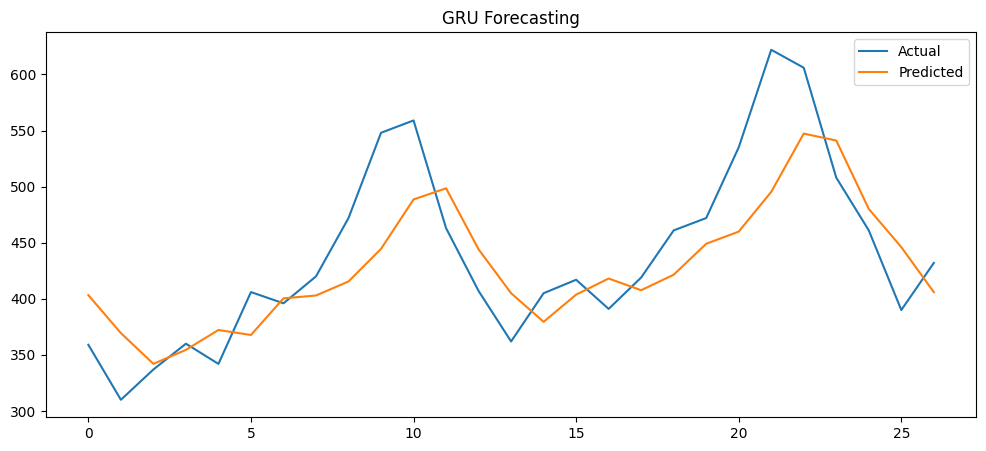

In [7]:

plt.figure(figsize=(12,5))
plt.plot(actual, label="Actual")
plt.plot(pred, label="Predicted")
plt.title("GRU Forecasting")
plt.legend()
plt.show()


In [8]:

last_seq = data_scaled[-seq_len:]
last_seq = last_seq.reshape(1, seq_len, 1)

next_pred = model.predict(last_seq)
next_pred = scaler.inverse_transform(next_pred)

print("Next Month Passenger Prediction:", next_pred[0][0])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step
Next Month Passenger Prediction: 427.79916
